In [1]:
import numpy as np
import pywt
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal

In [2]:
import numpy as np

n = 10
result = np.r_[-n//2+1:n//2+1]
print(np.arange(n, n + n))
print(result)
# Output: [1 2 3 0 4 5 6]
# QUESTION: when indexing, do we need to chop negative and positive modes, or do we just need the positive modes? 
# np.r_[] runs from -5 to 5 

[10 11 12 13 14 15 16 17 18 19]
[-4 -3 -2 -1  0  1  2  3  4  5]


In [62]:
def freq(n: int): return np.arange(n//2+1) * 2j * 3.14159

def real(coef, n: int):
    cos, sin = coef.real, coef.imag[1:-(n//-2)]
    return np.concatenate((cos, sin[::-1]), 0)

real(freq(40), n=40)

array([  0.     ,   0.     ,   0.     ,   0.     ,   0.     ,   0.     ,
         0.     ,   0.     ,   0.     ,   0.     ,   0.     ,   0.     ,
         0.     ,   0.     ,   0.     ,   0.     ,   0.     ,   0.     ,
         0.     ,   0.     ,   0.     , 119.38042, 113.09724, 106.81406,
       100.53088,  94.2477 ,  87.96452,  81.68134,  75.39816,  69.11498,
        62.8318 ,  56.54862,  50.26544,  43.98226,  37.69908,  31.4159 ,
        25.13272,  18.84954,  12.56636,   6.28318])

In [60]:
def freq(n: int, offset: int = 0): 
    return (np.arange(n//2 + 1) + offset) * 2j * 3.14159
new = np.arange(n, n + n)
real(freq(10, offset=10), n=10)

array([ 0.     ,  0.     ,  0.     ,  0.     ,  0.     ,  0.     ,
       87.96452, 81.68134, 75.39816, 69.11498])

In [63]:
np.arange(n//2 + 1) + 10

array([10, 11, 12, 13, 14, 15])

In [55]:
freq(10, offset=10)

array([0.+62.8318j , 0.+69.11498j, 0.+75.39816j, 0.+81.68134j,
       0.+87.96452j, 0.+94.2477j ])

In [ ]:
def fn(n: int, x):
    return np.moveaxis(real(np.moveaxis(np.exp(x * -freq(n)), -1, 0), n), 0, -1)

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])

In [78]:
full_fft = np.fft.rfft(np.linspace(0, 100), axis=0, norm="forward")
n_modes = len(full_fft) # extract only modes [offset, offset + n//2]
coef = full_fft[5:min(5 + n_modes, n_modes)]
print(full_fft)
print(coef)

[50.         +0.j         -1.02040816+16.21892331j
 -1.02040816 +8.07736234j -1.02040816 +5.34916692j
 -1.02040816 +3.9742274j  -1.02040816 +3.14049341j
 -1.02040816 +2.57725683j -1.02040816 +2.16847773j
 -1.02040816 +1.85611556j -1.02040816 +1.60790598j
 -1.02040816 +1.40447135j -1.02040816 +1.23346158j
 -1.02040816 +1.08662433j -1.02040816 +0.95822705j
 -1.02040816 +0.84415505j -1.02040816 +0.74136993j
 -1.02040816 +0.64757071j -1.02040816 +0.56097413j
 -1.02040816 +0.48016763j -1.02040816 +0.40400817j
 -1.02040816 +0.33155071j -1.02040816 +0.26199629j
 -1.02040816 +0.19465327j -1.02040816 +0.12890753j
 -1.02040816 +0.06419864j -1.02040816 +0.j        ]
[-1.02040816+3.14049341j -1.02040816+2.57725683j -1.02040816+2.16847773j
 -1.02040816+1.85611556j -1.02040816+1.60790598j -1.02040816+1.40447135j
 -1.02040816+1.23346158j -1.02040816+1.08662433j -1.02040816+0.95822705j
 -1.02040816+0.84415505j -1.02040816+0.74136993j -1.02040816+0.64757071j
 -1.02040816+0.56097413j -1.02040816+0.48016

In [ ]:
n_coef = len(np.linspace(0, 100)) // 2 + 1
end_idx = min(5 + n_coef, len(full_fft)) # concentrate on the high frequency range here, chop off the low frequency modes
if 10 < len(full_fft):
    coef = full_fft[10:end_idx]
    # Pad if needed
    if len(coef) < n_coef:
        coef = np.pad(coef, (0, n_coef - len(coef)))
else:
    # Offset beyond signal frequencies, return zeros
    coef = np.zeros(n_coef, dtype=complex)

In [83]:
end_idx

26

In [ ]:
def transform(x: X, offset: int = 0):
        """
        Transform physical space to spectral coefficients
        for offset modes, we need to:
        1. take full FFT
        2. extract only the offset frequency range
        3. store with proper normalization
        """
        full_fft = np.fft.rfft(x, axis=0, norm="forward")
        
        if offset == 0:
            coef = full_fft # standard case: use all modes
        else:
            n_modes = len(full_fft) # extract only modes [offset, offset + n//2]
            coef = full_fft[offset:min(offset + n_modes, len(full_fft))]
        
        coef = coef.at[1:-(len(coef)//-2)].multiply(2) # normalize
        return MultiScaleFourier(real(coef, len(coef)), offset=offset)

array([ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

#### Experiment 1: Different fourier modes are responsible for different portions of the wavelet decomposition

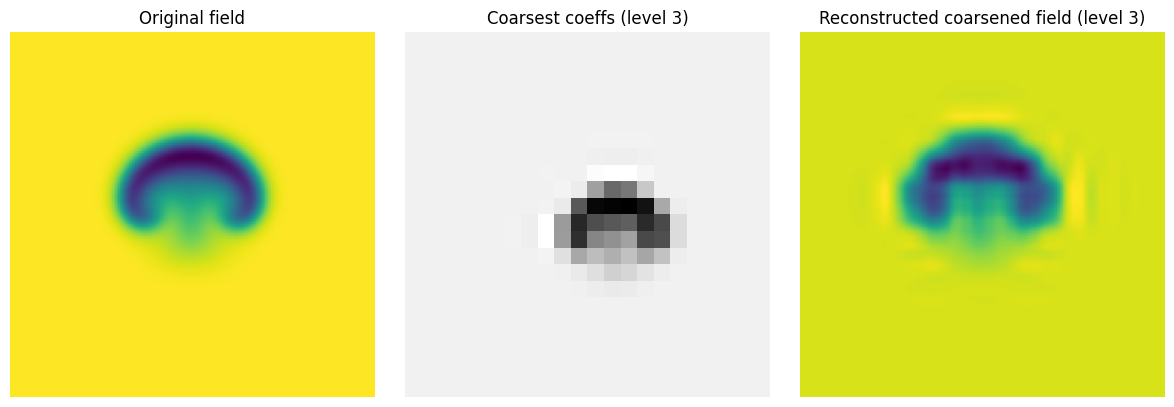

In [78]:
# NOTE: different portions of the wavelet decomposition are responsible for different parts of the solution
true_data = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/curledwake/_u_full_hard.npy')
signal = np.squeeze(true_data[1, :, :, :][43])   # removes singleton dims → (129,129)

wavelet = 'db4'
levels = 3  # how many scales to coarsen

# --- Multi-level decomposition ---
coeffs = pywt.wavedec2(signal, wavelet=wavelet, mode='symmetric', level=levels)

# coeffs = [cA_L, (cH_L, cV_L, cD_L), ..., (cH_1, cV_1, cD_1)]
# Keep only the coarsest approximation
cA_L = coeffs[0]
zero_details = [(np.zeros_like(cH), np.zeros_like(cV), np.zeros_like(cD)) for (cH, cV, cD) in coeffs[1:]]

# --- Reconstruct coarsened signal ---
coarsened = pywt.waverec2([cA_L, *zero_details], wavelet=wavelet, mode='symmetric')
coarsened = coarsened[:signal.shape[0], :signal.shape[1]]

# --- Visualization ---
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(signal, cmap='viridis')
axs[0].set_title("Original field")

axs[1].imshow(cA_L, cmap='gray')
axs[1].set_title(f"Coarsest coeffs (level {levels})")

axs[2].imshow(coarsened, cmap='viridis')
axs[2].set_title(f"Reconstructed coarsened field (level {levels})")

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()

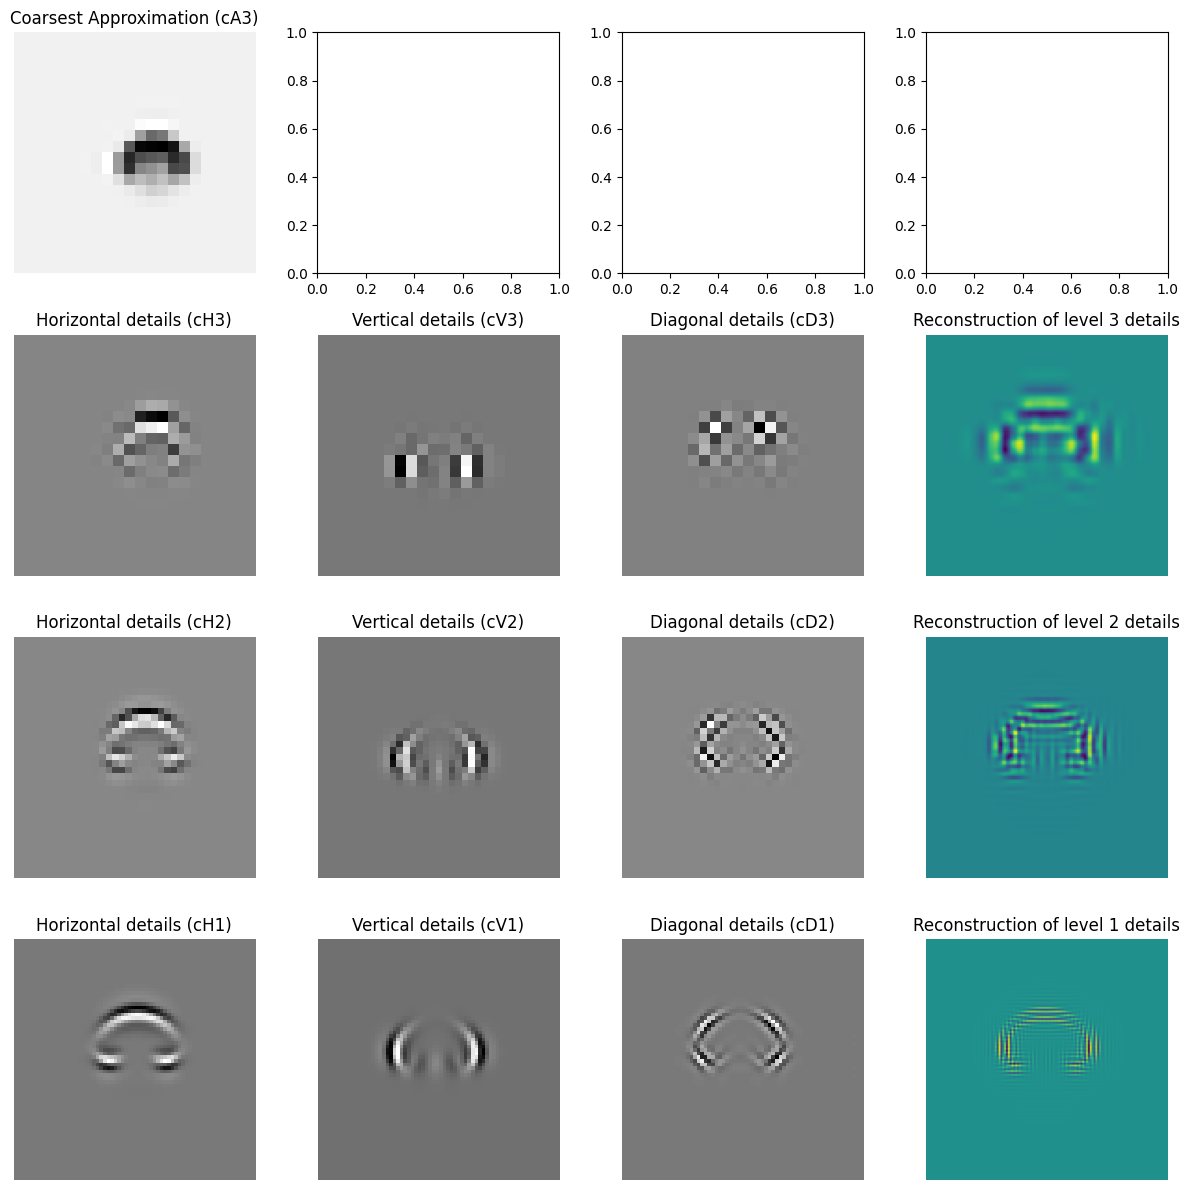

In [79]:
# --- Visualize all levels ---
fig, axs = plt.subplots(levels+1, 4, figsize=(12, 3*(levels+1)))

# Approximation at the coarsest scale
axs[0,0].imshow(coeffs[0], cmap='gray')
axs[0,0].set_title("Coarsest Approximation (cA3)")
axs[0,0].axis('off')

for j, (cH, cV, cD) in enumerate(coeffs[1:], 1):
    axs[j,0].imshow(cH, cmap='gray')
    axs[j,0].set_title(f"Horizontal details (cH{levels-j+1})")
    axs[j,0].axis('off')
    
    axs[j,1].imshow(cV, cmap='gray')
    axs[j,1].set_title(f"Vertical details (cV{levels-j+1})")
    axs[j,1].axis('off')
    
    axs[j,2].imshow(cD, cmap='gray')
    axs[j,2].set_title(f"Diagonal details (cD{levels-j+1})")
    axs[j,2].axis('off')
    
    # Reconstruct using just this level’s detail
    coeffs_zero = [np.zeros_like(coeffs[0])] + [
        (np.zeros_like(ch), np.zeros_like(cv), np.zeros_like(cd)) for (ch, cv, cd) in coeffs[1:]
    ]
    coeffs_zero[j] = (cH, cV, cD)
    detail_level = pywt.waverec2(coeffs_zero, wavelet)
    axs[j,3].imshow(detail_level, cmap='viridis')
    axs[j,3].set_title(f"Reconstruction of level {levels-j+1} details")
    axs[j,3].axis('off')

plt.tight_layout()
plt.show()


In [80]:
# VERIFYING PERFECT RECONSTRUCTION
u_original = signal  # shape (H, W)
wav = "db4"

# Perform 3-level wavelet decomposition
coeffs = pywt.wavedec2(u_original, wavelet=wav, level=3)
# coeffs = [cA3, (cH3,cV3,cD3), (cH2,cV2,cD2), (cH1,cV1,cD1)]

# Full reconstruction (should equal u_original)
u_full = pywt.waverec2(coeffs, wavelet=wav)

# Reconstruct ONLY coarse approximation cA3
coeffs_cA_only = [coeffs[0]] + [(np.zeros_like(cH), np.zeros_like(cV), np.zeros_like(cD)) 
                                  for (cH, cV, cD) in coeffs[1:]]
u_coarse = pywt.waverec2(coeffs_cA_only, wavelet=wav)

# Reconstruct ONLY level 3 details
coeffs_L3_only = [np.zeros_like(coeffs[0])] + [coeffs[1]] + \
                 [(np.zeros_like(cH), np.zeros_like(cV), np.zeros_like(cD)) 
                  for (cH, cV, cD) in coeffs[2:]]
u_detail3 = pywt.waverec2(coeffs_L3_only, wavelet=wav)

# Reconstruct ONLY level 2 details
coeffs_L2_only = [np.zeros_like(coeffs[0])] + \
                 [(np.zeros_like(cH), np.zeros_like(cV), np.zeros_like(cD)) for (cH, cV, cD) in coeffs[1:2]] + \
                 [coeffs[2]] + \
                 [(np.zeros_like(cH), np.zeros_like(cV), np.zeros_like(cD)) for (cH, cV, cD) in coeffs[3:]]
u_detail2 = pywt.waverec2(coeffs_L2_only, wavelet=wav)

# Reconstruct ONLY level 1 details
coeffs_L1_only = [np.zeros_like(coeffs[0])] + \
                 [(np.zeros_like(cH), np.zeros_like(cV), np.zeros_like(cD)) for (cH, cV, cD) in coeffs[1:3]] + \
                 [coeffs[3]]
u_detail1 = pywt.waverec2(coeffs_L1_only, wavelet=wav)

# THE PROOF: Check if sum equals original
u_sum = u_coarse + u_detail3 + u_detail2 + u_detail1

# Verify
print(f"Max absolute difference: {np.max(np.abs(u_full - u_sum))}")
print(f"Relative error: {np.linalg.norm(u_full - u_sum) / np.linalg.norm(u_full)}")

Max absolute difference: 2.086162567138672e-07
Relative error: 1.8267142820604931e-07


Frequency analysis of the different bands:

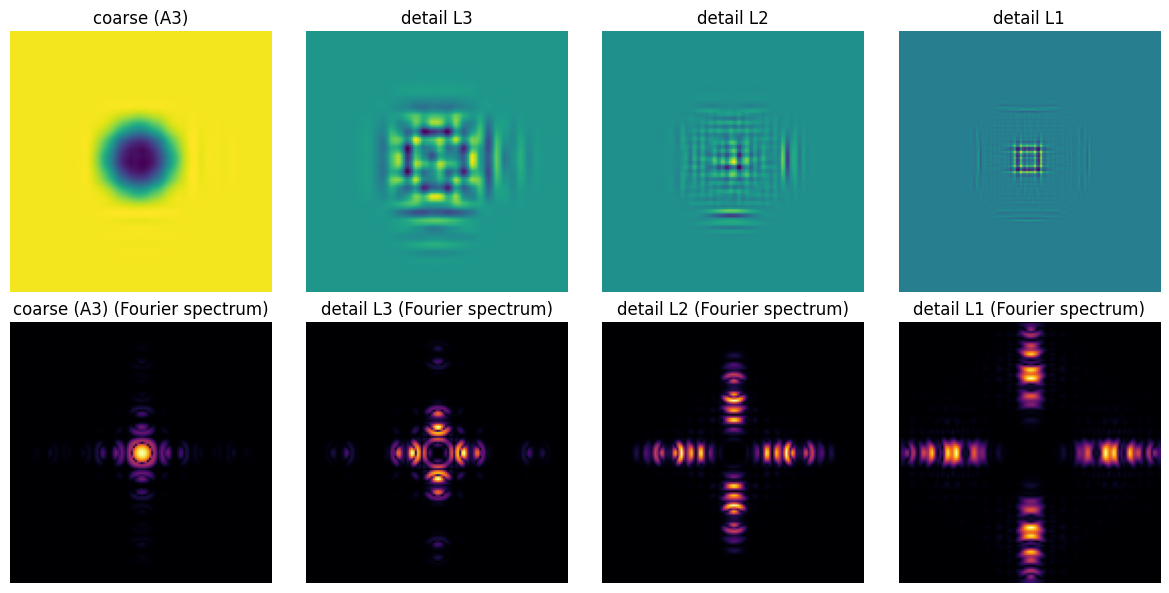

coarse (A3) : dominant frequency radius ≤ 4.1 / 91.9
detail L3   : dominant frequency radius ≤ 23.0 / 91.9
detail L2   : dominant frequency radius ≤ 43.1 / 91.9
detail L1   : dominant frequency radius ≤ 62.0 / 91.9


In [68]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

def dominant_frequency_band(u_component, frac=0.99):
    """Estimate frequency radius covering `frac` of spectral energy."""
    fft_signal = np.fft.fftshift(np.fft.fft2(u_component))
    power_spectrum = np.abs(fft_signal)**2
    nx, ny = power_spectrum.shape
    cx, cy = nx//2, ny//2

    # Compute radial distance grid
    kx = np.arange(-cx, nx-cx)
    ky = np.arange(-cy, ny-cy)
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    kr = np.sqrt(KX**2 + KY**2)

    # Sort by radius
    rvals = kr.flatten()
    pvals = power_spectrum.flatten()
    idx = np.argsort(rvals)
    r_sorted, p_sorted = rvals[idx], pvals[idx]
    cum_energy = np.cumsum(p_sorted) / np.sum(p_sorted)

    # Radius enclosing desired fraction of total energy
    r_cut = r_sorted[np.searchsorted(cum_energy, frac)]
    return r_cut, rvals.max()

def plot_spectrum(u_component, title):
    fft_signal = np.fft.fftshift(np.fft.fft2(u_component))
    plt.imshow(np.log1p(np.abs(fft_signal)), cmap='inferno')
    plt.title(title)
    plt.axis('off')

# --- Compute frequency bands for each wavelet component ---
components = {
    "coarse (A3)": u_coarse,
    "detail L3": u_detail3,
    "detail L2": u_detail2,
    "detail L1": u_detail1
}

plt.figure(figsize=(12, 6))
for i, (name, comp) in enumerate(components.items(), 1):
    plt.subplot(2, 4, i)
    plt.imshow(comp, cmap='viridis')
    plt.title(name)
    plt.axis('off')

    plt.subplot(2, 4, i+4)
    plot_spectrum(comp, f"{name} (Fourier spectrum)")

plt.tight_layout()
plt.show()

# --- Estimate frequency ranges numerically ---
for name, comp in components.items():
    r_cut, r_max = dominant_frequency_band(comp, frac=0.99)
    print(f"{name:12s}: dominant frequency radius ≤ {r_cut:.1f} / {r_max:.1f}")


In [69]:
components = {
    "A3": u_coarse,
    "D3": u_detail3,
    "D2": u_detail2,
    "D1": u_detail1
}

names = list(components.keys())
n = len(names)

print("Inner products between wavelet subbands:")
for i in range(n):
    for j in range(i+1, n):
        ui, uj = components[names[i]], components[names[j]]
        inner = np.sum(ui * uj)
        norm_i = np.linalg.norm(ui)
        norm_j = np.linalg.norm(uj)
        corr = inner / (norm_i * norm_j)
        print(f"⟨{names[i]}, {names[j]}⟩ / (‖·‖): {corr:.2e}")


Inner products between wavelet subbands:
⟨A3, D3⟩ / (‖·‖): -1.78e-09
⟨A3, D2⟩ / (‖·‖): -2.91e-09
⟨A3, D1⟩ / (‖·‖): 7.00e-09
⟨D3, D2⟩ / (‖·‖): -7.91e-09
⟨D3, D1⟩ / (‖·‖): 6.88e-10
⟨D2, D1⟩ / (‖·‖): 3.85e-09


In [70]:
def fft_inner_product(u1, u2):
    F1 = np.fft.fft2(u1)
    F2 = np.fft.fft2(u2)
    return np.sum(F1 * np.conj(F2))

print("\nInner products in Fourier domain:")
for i in range(n):
    for j in range(i+1, n):
        val = fft_inner_product(components[names[i]], components[names[j]])
        norm_i = np.sqrt(fft_inner_product(components[names[i]], components[names[i]]))
        norm_j = np.sqrt(fft_inner_product(components[names[j]], components[names[j]]))
        corr = np.abs(val / (norm_i * norm_j))
        print(f"⟨F({names[i]}), F({names[j]})⟩ / (‖·‖): {corr:.2e}")



Inner products in Fourier domain:
⟨F(A3), F(D3)⟩ / (‖·‖): 2.85e-09
⟨F(A3), F(D2)⟩ / (‖·‖): 9.16e-09
⟨F(A3), F(D1)⟩ / (‖·‖): 4.26e-09
⟨F(D3), F(D2)⟩ / (‖·‖): 5.83e-09
⟨F(D3), F(D1)⟩ / (‖·‖): 9.35e-10
⟨F(D2), F(D1)⟩ / (‖·‖): 1.98e-09


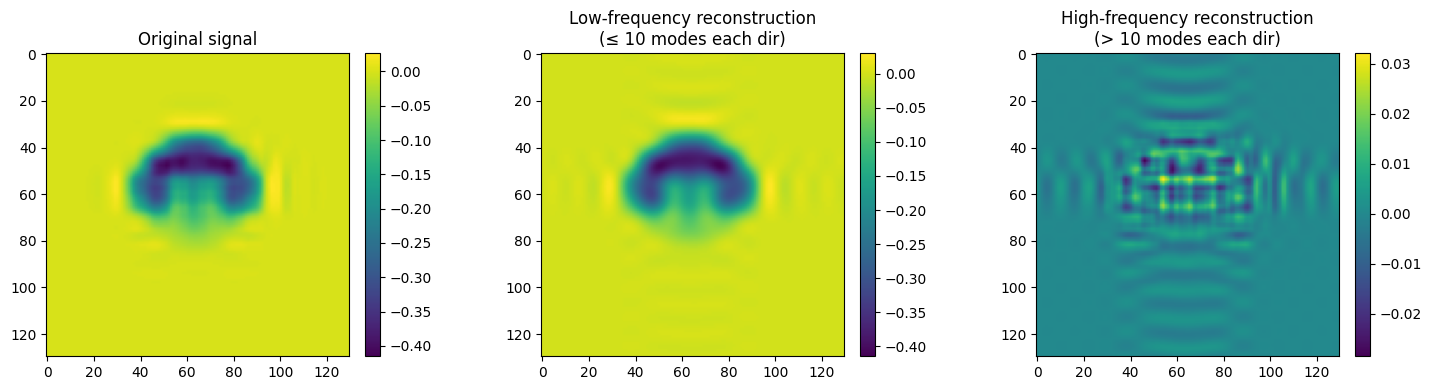

In [82]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
signal = u_coarse  # your 2D array
fft_signal = np.fft.fft2(signal)
fft_shifted = np.fft.fftshift(fft_signal)  # center low-freq at middle

nx, ny = signal.shape
keep = 10  # number of low-frequency modes to keep in each direction

# --- Create mask for LOW frequencies ---
mask_low = np.zeros_like(fft_shifted, dtype=bool)
cx, cy = nx // 2, ny // 2
mask_low[cx-keep:cx+keep+1, cy-keep:cy+keep+1] = True

# --- Low-frequency reconstruction (COARSE features) ---
fft_low = np.zeros_like(fft_shifted)
fft_low[mask_low] = fft_shifted[mask_low]
recon_low = np.fft.ifft2(np.fft.ifftshift(fft_low)).real

# --- High-frequency reconstruction (DETAILS only) ---
fft_high = np.zeros_like(fft_shifted)
fft_high[~mask_low] = fft_shifted[~mask_low]
recon_high = np.fft.ifft2(np.fft.ifftshift(fft_high)).real

# --- Plot results ---
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title("Original signal")
plt.imshow(signal, cmap='viridis')
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1,3,2)
plt.title(f"Low-frequency reconstruction\n(≤ {keep} modes each dir)")
plt.imshow(recon_low, cmap='viridis')
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1,3,3)
plt.title(f"High-frequency reconstruction\n(> {keep} modes each dir)")
plt.imshow(recon_high, cmap='viridis')
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


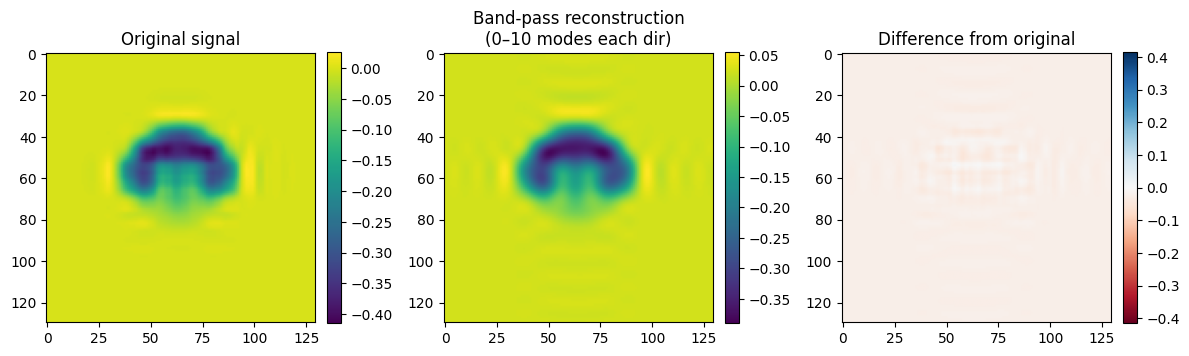

In [110]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
signal = u_coarse  # your 2D array
fft_signal = np.fft.fft2(signal)
fft_shifted = np.fft.fftshift(fft_signal)  # center low-freq at middle

nx, ny = signal.shape
inner = 0   # lower cutoff (exclude very low frequencies)
outer = 10   # upper cutoff (exclude very high frequencies)

# --- Create band-pass mask (15–25 modes each direction) ---
mask_band = np.zeros_like(fft_shifted, dtype=bool)
cx, cy = nx // 2, ny // 2
mask_band[cx-outer:cx+outer+1, cy-outer:cy+outer+1] = True   # inner square
mask_band[cx-inner:cx+inner+1, cy-inner:cy+inner+1] = False  # remove center region

# --- Band-pass reconstruction (MID frequencies) ---
fft_band = np.zeros_like(fft_shifted)
fft_band[mask_band] = fft_shifted[mask_band]
recon_band = np.fft.ifft2(np.fft.ifftshift(fft_band)).real

# --- For comparison: full reconstruction ---
recon_full = np.fft.ifft2(np.fft.ifftshift(fft_shifted)).real

# --- Plot results ---
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original signal")
plt.imshow(signal, cmap='viridis')
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1,3,2)
plt.title(f"Band-pass reconstruction\n({inner}–{outer} modes each dir)")
plt.imshow(recon_band, cmap='viridis')
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1,3,3)
plt.title("Difference from original")
plt.imshow(signal - recon_band, cmap='RdBu', vmin=-np.max(np.abs(signal)), vmax=np.max(np.abs(signal)))
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


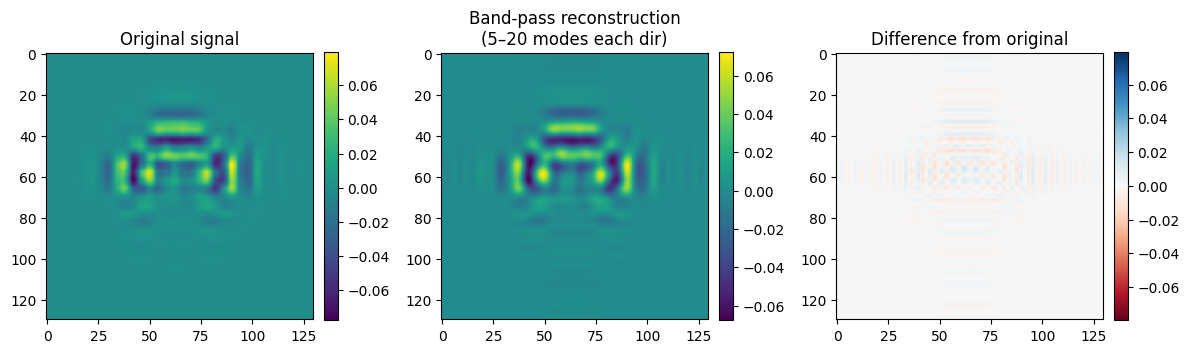

In [114]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
signal = u_detail3  # your 2D array
fft_signal = np.fft.fft2(signal)
fft_shifted = np.fft.fftshift(fft_signal)  # center low-freq at middle

nx, ny = signal.shape
inner = 5   # lower cutoff (exclude very low frequencies)
outer = 20   # upper cutoff (exclude very high frequencies)

# --- Create band-pass mask (15–25 modes each direction) ---
mask_band = np.zeros_like(fft_shifted, dtype=bool)
cx, cy = nx // 2, ny // 2
mask_band[cx-outer:cx+outer+1, cy-outer:cy+outer+1] = True   # inner square
mask_band[cx-inner:cx+inner+1, cy-inner:cy+inner+1] = False  # remove center region

# --- Band-pass reconstruction (MID frequencies) ---
fft_band = np.zeros_like(fft_shifted)
fft_band[mask_band] = fft_shifted[mask_band]
recon_band = np.fft.ifft2(np.fft.ifftshift(fft_band)).real

# --- For comparison: full reconstruction ---
recon_full = np.fft.ifft2(np.fft.ifftshift(fft_shifted)).real

# --- Plot results ---
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original signal")
plt.imshow(signal, cmap='viridis')
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1,3,2)
plt.title(f"Band-pass reconstruction\n({inner}–{outer} modes each dir)")
plt.imshow(recon_band, cmap='viridis')
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1,3,3)
plt.title("Difference from original")
plt.imshow(signal - recon_band, cmap='RdBu', vmin=-np.max(np.abs(signal)), vmax=np.max(np.abs(signal)))
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


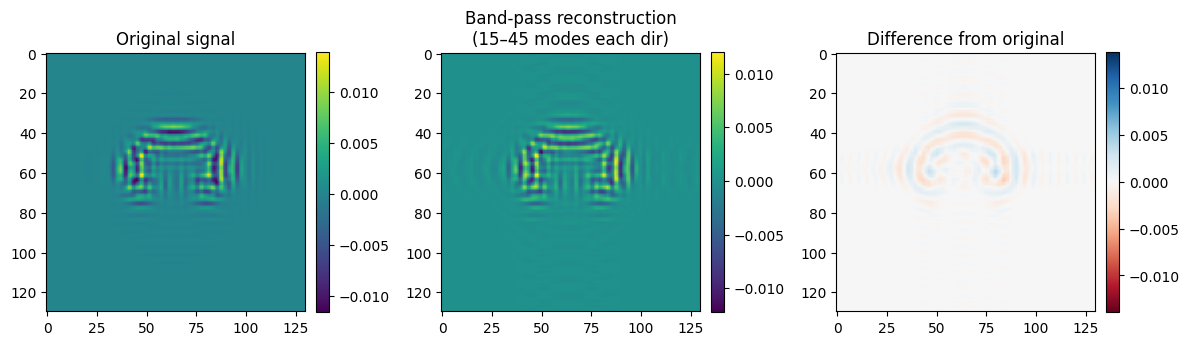

In [117]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
signal = u_detail2  # your 2D array
fft_signal = np.fft.fft2(signal)
fft_shifted = np.fft.fftshift(fft_signal)  # center low-freq at middle

nx, ny = signal.shape
inner = 15   # lower cutoff (exclude very low frequencies)
outer = 45   # upper cutoff (exclude very high frequencies)

# --- Create band-pass mask (15–25 modes each direction) ---
mask_band = np.zeros_like(fft_shifted, dtype=bool)
cx, cy = nx // 2, ny // 2
mask_band[cx-outer:cx+outer+1, cy-outer:cy+outer+1] = True   # inner square
mask_band[cx-inner:cx+inner+1, cy-inner:cy+inner+1] = False  # remove center region

# --- Band-pass reconstruction (MID frequencies) ---
fft_band = np.zeros_like(fft_shifted)
fft_band[mask_band] = fft_shifted[mask_band]
recon_band = np.fft.ifft2(np.fft.ifftshift(fft_band)).real

# --- For comparison: full reconstruction ---
recon_full = np.fft.ifft2(np.fft.ifftshift(fft_shifted)).real

# --- Plot results ---
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original signal")
plt.imshow(signal, cmap='viridis')
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1,3,2)
plt.title(f"Band-pass reconstruction\n({inner}–{outer} modes each dir)")
plt.imshow(recon_band, cmap='viridis')
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1,3,3)
plt.title("Difference from original")
plt.imshow(signal - recon_band, cmap='RdBu', vmin=-np.max(np.abs(signal)), vmax=np.max(np.abs(signal)))
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


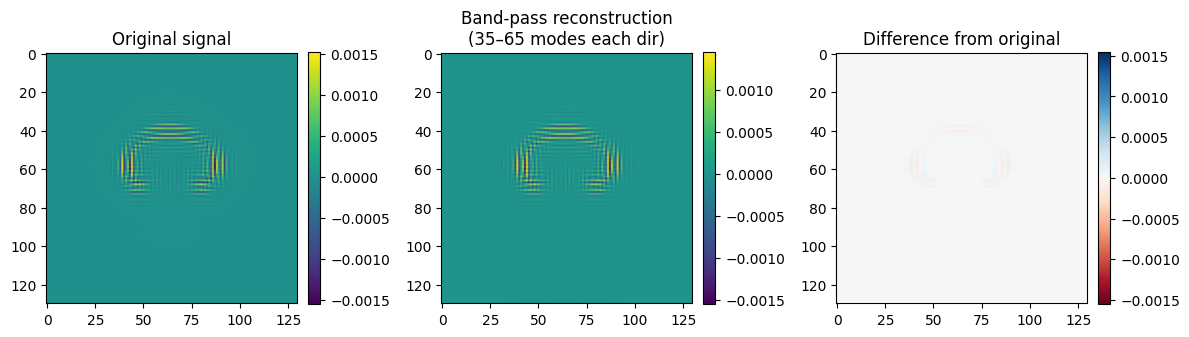

In [118]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
signal = u_detail1  # your 2D array
fft_signal = np.fft.fft2(signal)
fft_shifted = np.fft.fftshift(fft_signal)  # center low-freq at middle

nx, ny = signal.shape
inner = 35   # lower cutoff (exclude very low frequencies)
outer = 65   # upper cutoff (exclude very high frequencies)

# --- Create band-pass mask (15–25 modes each direction) ---
mask_band = np.zeros_like(fft_shifted, dtype=bool)
cx, cy = nx // 2, ny // 2
mask_band[cx-outer:cx+outer+1, cy-outer:cy+outer+1] = True   # inner square
mask_band[cx-inner:cx+inner+1, cy-inner:cy+inner+1] = False  # remove center region

# --- Band-pass reconstruction (MID frequencies) ---
fft_band = np.zeros_like(fft_shifted)
fft_band[mask_band] = fft_shifted[mask_band]
recon_band = np.fft.ifft2(np.fft.ifftshift(fft_band)).real

# --- For comparison: full reconstruction ---
recon_full = np.fft.ifft2(np.fft.ifftshift(fft_shifted)).real

# --- Plot results ---
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original signal")
plt.imshow(signal, cmap='viridis')
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1,3,2)
plt.title(f"Band-pass reconstruction\n({inner}–{outer} modes each dir)")
plt.imshow(recon_band, cmap='viridis')
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1,3,3)
plt.title("Difference from original")
plt.imshow(signal - recon_band, cmap='RdBu', vmin=-np.max(np.abs(signal)), vmax=np.max(np.abs(signal)))
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


#### Experiment 2: Testing whether NM model can learn high frequency modes truncated differently on "detail" data

In [1]:
import pywt
import numpy as np
from pathlib import Path
from tqdm import tqdm


def zero_triplet(triplet):
    cH, cV, cD = triplet
    return (np.zeros_like(cH), np.zeros_like(cV), np.zeros_like(cD))


def reconstruct_component(coeffs, level, component, wav):
    """component = 'approx' or level number (1..level)"""
    if component == "approx":
        new_coeffs = [coeffs[0]] + [zero_triplet(t) for t in coeffs[1:]]
    else:
        new_coeffs = [np.zeros_like(coeffs[0])]
        for i in range(1, level+1):
            if i == component:
                new_coeffs.append(coeffs[i])
            else:
                new_coeffs.append(zero_triplet(coeffs[i]))
    return pywt.waverec2(new_coeffs, wavelet=wav)


def generate_wavelet_data(data, wav, level, out_dir):
    """
    data shape: (B, T, H, W, C)
    Saves 4 arrays:
        u_full.npy
        u_coarse.npy
        u_detail1.npy
        u_detail2.npy
        u_detail3.npy
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    B, T, H, W, C = data.shape
    assert C == 1
    data = data[..., 0]   # now (B,T,H,W)

    # pre-allocate output arrays
    u_full   = np.zeros((B, T, H, W), dtype=np.float32)
    u_coarse = np.zeros_like(u_full)
    u_detail = {k: np.zeros_like(u_full) for k in range(1, level+1)}

    for b in tqdm(range(B), desc="Samples"):
        for t in range(T):
            u = data[b, t]  # shape (H, W)
            Hpad = H + (H % 2) 
            Wpad = W + (W % 2)
            pad_h = Hpad - H
            pad_w = Wpad - W
            u_padded = np.pad(u, ((0, pad_h), (0, pad_w)), mode="wrap")

            coeffs = pywt.wavedec2(u_padded, wavelet=wav, level=level)
            u_rec = pywt.waverec2(coeffs, wavelet=wav)
            u_full[b, t] = u_rec[:H, :W]
            coarse = reconstruct_component(coeffs, level, "approx", wav)
            u_coarse[b, t] = coarse[:H, :W]
            for lvl in range(1, level+1):
                detail = reconstruct_component(coeffs, level, lvl, wav)
                u_detail[lvl][b, t] = detail[:H, :W]

    # save outputs
    np.save(out_dir / "u_full.npy", u_full)
    np.save(out_dir / "u_coarse.npy", u_coarse)
    # save ics, and full separately, follow the format in the previous code
    for lvl in range(1, level+1):
        np.save(out_dir / f"u_detail{lvl}.npy", u_detail[lvl])

    print("Done! Saved:", out_dir)

data_path = Path("/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/curledwake/_u_ic_hard.npy")
out_dir = Path("/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/curledwake/wavelet_data")
out_dir.mkdir(parents=True, exist_ok=True)
true_data = np.load(data_path)
wav = "db4"
level = 3

generate_wavelet_data(true_data, wav, level, out_dir)


Samples: 100%|██████████| 128/128 [00:01<00:00, 90.12it/s]


Done! Saved: /mnt/home/abhagava/Neural-Spectral-Methods/src/pde/curledwake/wavelet_data


In [1]:
# TODO: last thing i need to check is u_ic_raw_hard 
import matplotlib.pyplot as plt
import numpy as np

data = np.load("/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/curledwake/_u_ic_raw_hard.npy")  # (128, T, 128, 128, 1)
data.shape

(128, 129, 129)

In [4]:
data = np.load("/mnt/home/abhagava/Neural-Spectral-Methods/wavelet_decomp/u_ic_raw_coarse.npy")  # (128, T, 128, 128, 1)
data.shape

(128, 129, 129)

In [21]:
import numpy as np
import matplotlib.pyplot as plt 
data = np.load("/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/curledwake/_u_ic_hard.npy")  # (128, T, 128, 128, 1)
data.shape

(128, 2, 128, 128, 1)

In [ ]:
def identify_dominant_fourier_mode_range(decomposition): 

    pass 


In [12]:
uhat_8_length_scale = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/navierstokes/u.Re=8000:T=3:None.npy')
uhat_4_length_scale = np.load('/mnt/home/abhagava/Neural-Spectral-Methods/src/pde/navierstokes/u.Re=2999:T=3:None.npy')

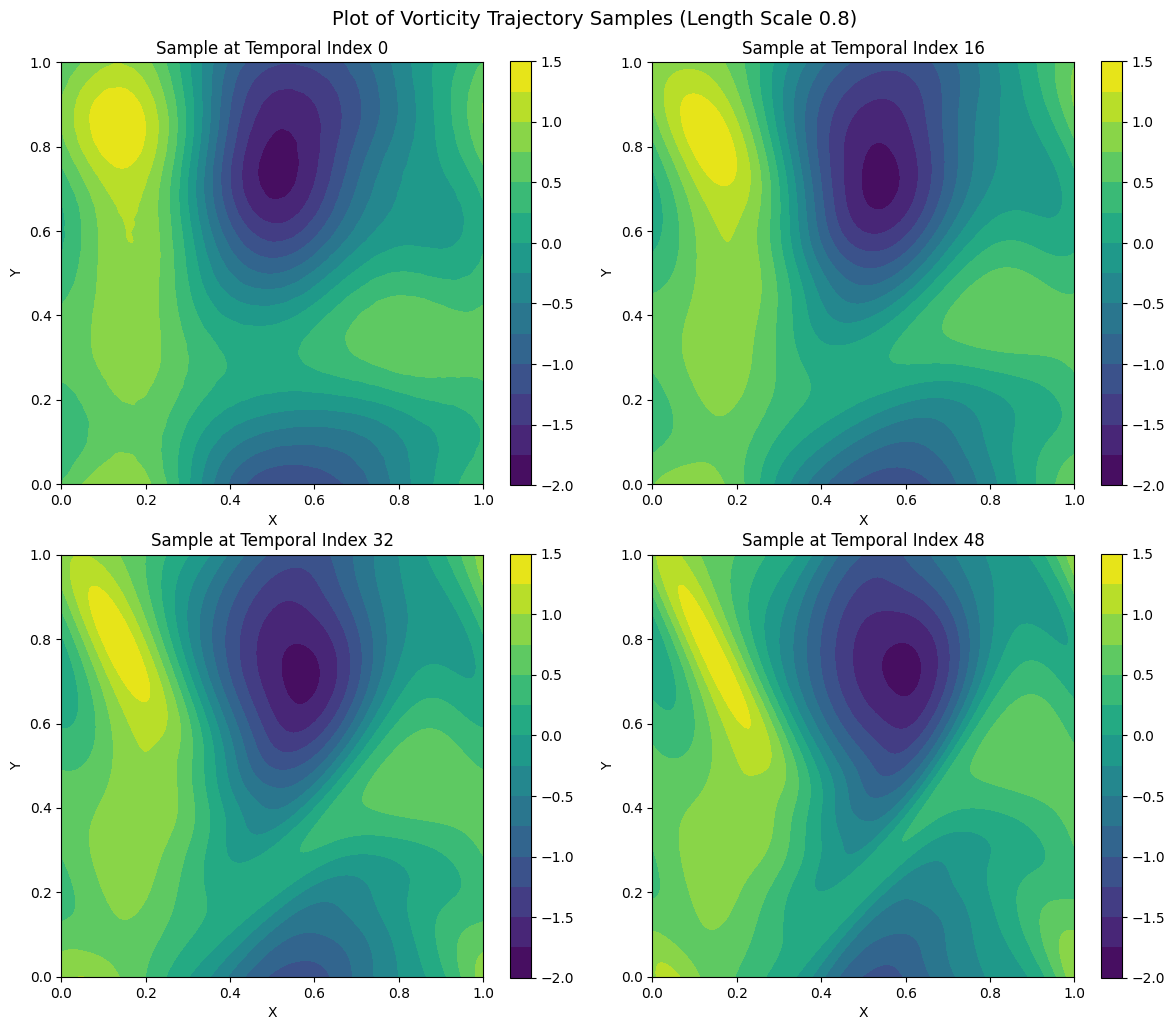

In [13]:
# plot samples from a single trajectory of data 
param1_data = uhat_8_length_scale[10]
sample_indices = np.array([0, 16, 32, 48])
param1_data_samples = param1_data[sample_indices, :, :]


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
# Create coordinate grids for the 257x257 spatial domain
x = np.linspace(0, 1, 257) 
y = np.linspace(0, 1, 257)
X, Y = np.meshgrid(x, y)

for i in range(4):
    # Extract the 2D field
    field = param1_data_samples[i, :, :, 0]
    im = axes[i].contourf(X, Y, field, levels=15, cmap='viridis')
    # im = axes[i].imshow(field, origin='lower', cmap='viridis')
    axes[i].set_title(f'Sample at Temporal Index {sample_indices[i]}')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')
    axes[i].set_aspect('equal')
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.suptitle('Plot of Vorticity Trajectory Samples (Length Scale 0.8)', y=1.02, fontsize=14)
plt.show()


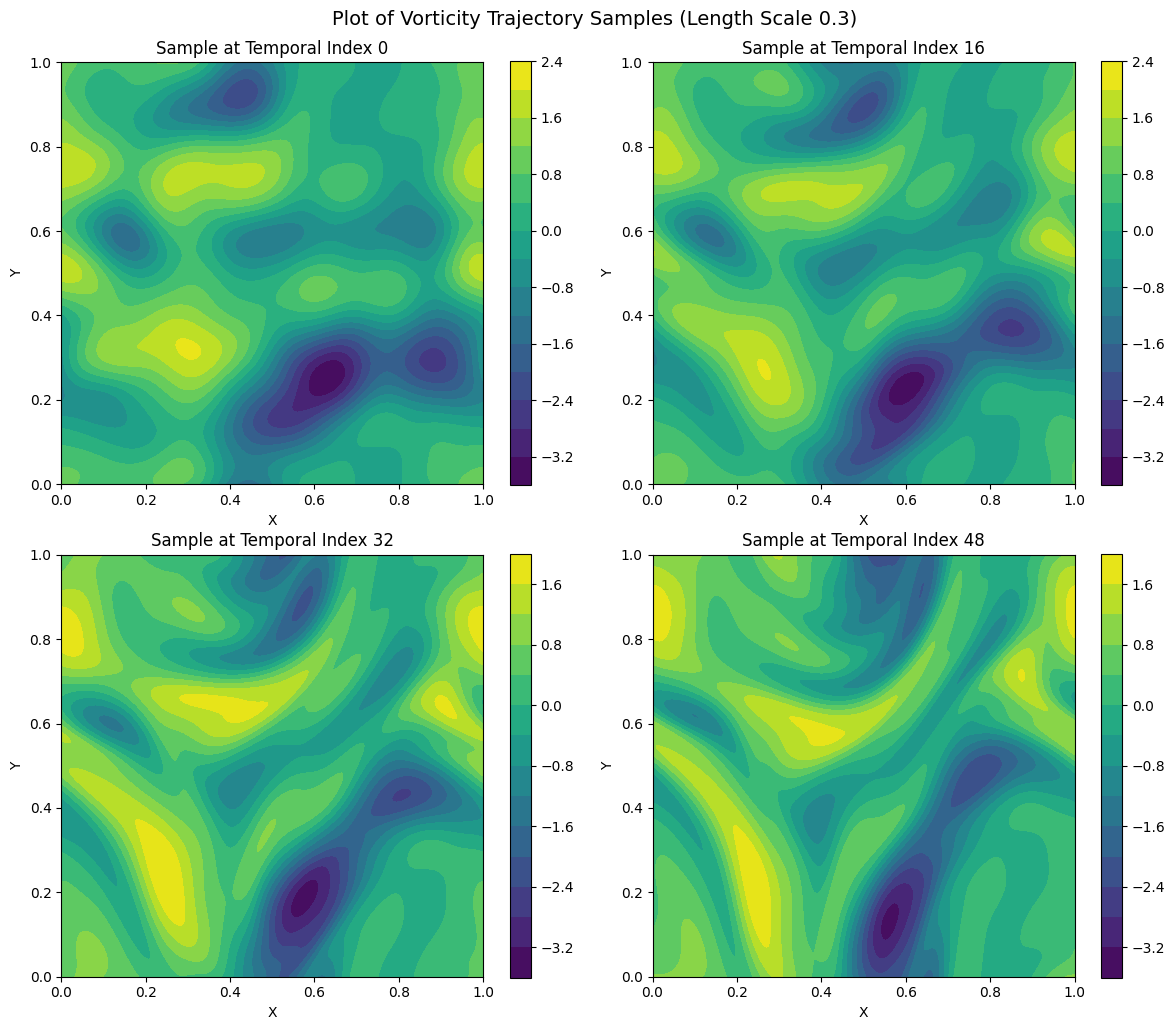

In [14]:
# plot samples from a single trajectory of data 
param1_data = uhat_4_length_scale[10]
sample_indices = np.array([0, 16, 32, 48])
param1_data_samples = param1_data[sample_indices, :, :]


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
# Create coordinate grids for the 257x257 spatial domain
x = np.linspace(0, 1, 257) 
y = np.linspace(0, 1, 257)
X, Y = np.meshgrid(x, y)

for i in range(4):
    # Extract the 2D field
    field = param1_data_samples[i, :, :, 0]
    im = axes[i].contourf(X, Y, field, levels=15, cmap='viridis')
    # im = axes[i].imshow(field, origin='lower', cmap='viridis')
    axes[i].set_title(f'Sample at Temporal Index {sample_indices[i]}')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')
    axes[i].set_aspect('equal')
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.suptitle('Plot of Vorticity Trajectory Samples (Length Scale 0.3)', y=1.02, fontsize=14)
plt.show()
